# Identifikation af abonnenters databrugssegmenter med PROC FASTCLUS

## Resumé

Et telekommunikationsanalyseteam ønsker at segmentere sin mobilabonnentbase efter **månedligt dataforbrug** uden at indføre vilkårlige GB-grænser. Ved hjælp af **PROC FASTCLUS** — SAS's højtydende *k*-means-klyngeprocedure — lader vi selve dataene inddele sig i latente forbrugsklasser (lette, moderate og tunge databrugere). FASTCLUS finder hvert segments centrum, tildeler hver abonnent til det nærmeste, og rapporterer, hvor rent segmenterne adskiller sig — hvilket omdanner én kontinuert forbrugsmetrik til en handlingsorienteret, datadrevet segmentering til planlægning af abonnementer og målrettet markedsføring.

## Datakilder

Alle data genereres direkte af det første DATA-trin — der er ingen eksterne filer eller netværkskald. Abonnenter er trukket fra en forbrugspopulation med tre komponenter, så de genfundne segmenter kan valideres mod en kendt facitliste.

| Datasæt | Rækker | Variabel | Type | Beskrivelse |
|---------|------|----------|------|-------------|
| `subscribers` | 1.500 | `id` | Num | Abonnent-id (1–1500) |
| `subscribers` | 1.500 | `data_gb` | Num | Månedligt mobildataforbrug i GB (metrikken vi klynger på) |
| `subscribers` | 1.500 | `segment_true` | Char | Latent segment brugt til at *generere* værdien (Let ≈ N(3,1²) 50 %, Moderat ≈ N(12,3²) 35 %, Tung ≈ N(35,8²) 15 %); holdt tilbage kun for at validere de genfundne segmenter — en rigtig analytiker ville ikke observere den |

# Identifikation af abonnenters databrugssegmenter

Mobiloperatører har sjældent en ren mærkning, der siger, at "dette er en tung databruger". Det de har, er en kontinuert metrik — gigabyte forbrugt pr. måned — hvis fordeling er **multimodal**: klynger af lette, moderate og storforbrugere overlapper på en enkelt akse. **Klyngeanalyse** behandler denne ene kolonne som et geometriproblem: den lokaliserer de naturlige massecentre i forbrugsfordelingen og tildeler hver abonnent til det nærmeste, uden håndplukkede grænseværdier.

I denne notesbog:

1. Genererer vi en realistisk syntetisk abonnentbase, hvis dataforbrug stammer fra tre skjulte segmenter.
2. Undersøger vi den marginale forbrugsfordeling for at bekræfte, at den er multimodal.
3. Standardiserer vi metrikken og kører **PROC FASTCLUS** for at inddele abonnenter i tre forbrugssegmenter.
4. Profilerer vi hvert genfundet segment på den oprindelige GB-skala og validerer derefter genfindingen mod den kendte facitliste.

Mærkningen `segment_true` genereres udelukkende, så vi kan bedømme klyngedannelsen til sidst — i produktion ville den ikke eksistere.

In [1]:
/* Syntetisér en abonnentbase fra tre latente forbrugssegmenter. */
/* Lette brugere dominerer; en lille hale af tunge brugere driver det meste af omsætningen. */
data subscribers;
   call streaminit(20260531);
   længde segment_true $8;
   gør id = 1 til 1500;
      u = rand('uniform');
      hvis u < 0.50 så gør;                 /* ~50% lette brugere        */
         segment_true = 'Let';
         data_gb = rand('normal', 3.0, 1.0);
      slut;
      ellers hvis u < 0.85 så gør;            /* ~35% moderate brugere     */
         segment_true = 'Moderat';
         data_gb = rand('normal', 12.0, 3.0);
      slut;
      ellers gør;                             /* ~15% tunge brugere/storforbrugere  */
         segment_true = 'Tung';
         data_gb = rand('normal', 35.0, 8.0);
      slut;
      hvis data_gb < 0.1 så data_gb = 0.1; /* forbrug kan ikke være negativt */
      uddata;
   slut;
   behold id data_gb segment_true;
kør;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Et første kig på den marginale fordeling

Før klyngedannelsen opsummerer vi den ene responsvariabel. Den brede spredning og afstanden mellem gennemsnittet og hovedparten af de lette brugere er de typiske tegn på en underliggende blanding af segmenter — et enkelt forbrugsniveau ville ikke kunne genskabe både den tætte lavforbrugsklynge og den lange højforbrugshale.

In [2]:
procedure gennemsnit data=subscribers n mean std min p25 median p75 max maxdec=2;
   label data_gb="Månedligt dataforbrug (GB)";
   var data_gb;
kør;

                                                  The MEANS Procedure

 Variable  Label                               N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Månedligt dataforbrug (GB)        100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ---------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Histogrammet gør multimodaliteten visuel: en høj spids af lette brugere nær 3 GB, en moderat pukkel nær 12 GB, og en spredt hale af tunge brugere, der strækker sig forbi 30 GB. Disse tre toppe er netop de segmenter, vi vil bede klyngedannelsen om at genfinde. Kernedensitetskurven følger den samme blandede form.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


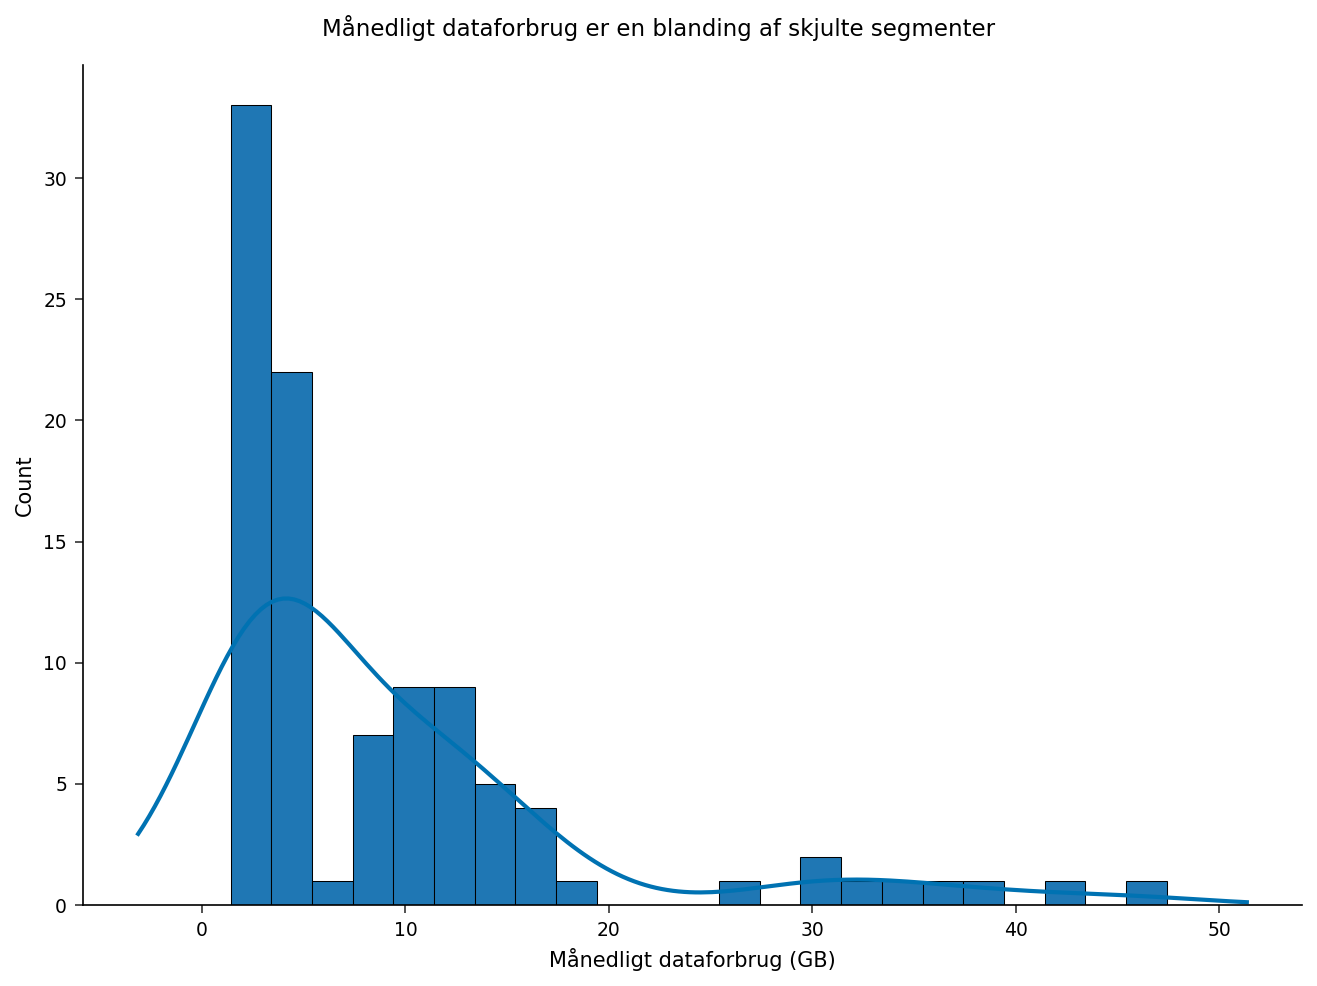

In [3]:
ods graphics on;
procedure sgplot data=subscribers;
   titel "Månedligt dataforbrug er en blanding af skjulte segmenter";
   histogram data_gb / binwidth=2;
   density   data_gb / type=kernel;
   xaxis mærkat="Månedligt dataforbrug (GB)";
kør;
titel;
ods graphics off;

## At sætte forbruget på en fælles skala

*k*-means inddeler punkter efter euklidisk afstand, så variablens rå skala styrer resultatet. Med én enkelt metrik betyder dette kun, at aksen omcentreres, men at standardisere til gennemsnit 0 / standardafvigelse 1 med **PROC STANDARD** er den vane, der holder arbejdsgangen korrekt, i det øjeblik en anden forbrugsmetrik (taleminutter, roamingdage) tilføjes. Vi klynger på den standardiserede kolonne og rapporterer resultaterne tilbage på den oprindelige GB-skala.

In [4]:
procedure standard data=subscribers out=subs_std mean=0 std=1;
   var data_gb;
kør;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Inddeling af abonnenter i tre forbrugssegmenter

Styret af domæneviden om lette / moderate / tunge niveauer beder vi **PROC FASTCLUS** om `MAXCLUSTERS=3`. Proceduren udlægger tre centre, tildeler hver abonnent til det nærmeste, genberegner centrene og itererer, indtil tildelingerne holder op med at flytte sig (`CONVERGE=` med et `MAXITER=`-loft). `SEED=` gør initialiseringen reproducerbar. `OUT=`-datasættet bærer hver abonnents `CLUSTER`-mærkning og dens `DISTANCE` til det tildelte centrum; `MEAN=` skriver segmenternes centroider.

Aflæs procedurens diagnostik for adskillelseskvalitet: en høj **R-Squared** (andelen af den samlede forbrugsvarians, som segmenterne forklarer) og en stor **Pseudo F** indikerer begge veladskilte, kompakte segmenter.

In [5]:
procedure fastclus data=subs_std seed=20260531
              maxclusters=3 maxiter=100 converge=1e-4
              out=clusters mean=centroids;
   label data_gb="Standardiseret dataforbrug (GB)";
   var data_gb;
   titel "Tre forbrugssegmenter via k-means";
kør;
titel;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Profilering af de fundne segmenter

Klyngemærkninger er kun anvendelige, når vi beskriver hvert segment i forretningsmæssige termer. Vi sammenfletter tildelingerne tilbage med det oprindelige (ikke-standardiserede) forbrug og opsummerer hvert segments størrelse og typiske forbrug på GB-skalaen — de tal, som et team for planlægning eller markedsføring rent faktisk handler ud fra.

In [6]:
data memberships;
   merge subscribers
         clusters(keep=id cluster distance);
   by id;
kør;

procedure gennemsnit data=memberships n mean min max maxdec=2;
   label data_gb="Månedligt dataforbrug (GB)" distance="Afstand til centrum"
         cluster="Klynge";
   class cluster;
   var data_gb distance;
kør;

procedure udskriv data=memberships(obs=10) noobs;
   label id="Abonnent-id" data_gb="Dataforbrug (GB)" cluster="Klynge"
         distance="Afstand" segment_true="Sandt segment";
   var id data_gb cluster distance segment_true;
kør;

                                                  The MEANS Procedure

                                Analysis Variable : data_gb Månedligt dataforbrug (GB)

        Klynge            N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                    Analysis Variable : DISTANCE Afstand til centrum

        Klynge            N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validering af de genfundne segmenter

Fordi dette er syntetiske data, har vi holdt `segment_true` tilbage — mærkningen brugt til at generere hver abonnent. Krydstabulering af modellens genfundne `CLUSTER` mod det sande segment viser, hvor rent inddelingen adskilte populationen. Stærk koncentration langs én entydig sammenhæng mellem klynge og segment indikerer en god genfinding; masse uden for diagonalen koncentreres, hvor grænserne mellem let/moderat eller moderat/tung overlapper.

In [7]:
procedure frekvenser data=memberships;
   label cluster="Klynge" segment_true="Sandt segment";
   tables cluster * segment_true / norow nocol nopercent;
kør;

                                                   The FREQ Procedure

Table of Klynge by Sandt segment

Klynge |       Let |   Moderat |      Tung |      Total
-------+-----------+-----------+-----------+-----------
1      |        54 |         3 |         0 |         57
-------+-----------+-----------+-----------+-----------
2      |         0 |         0 |         9 |          9
-------+-----------+-----------+-----------+-----------
3      |         0 |        33 |         1 |         34
-------+-----------+-----------+-----------+-----------
Total  |        54 |        36 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Fortolkning af resultaterne

- **Segmentcentre.** De tre klynger lander næsten præcis på de planlagte forbrugsniveauer — lette brugere nær **3 GB**, moderate brugere nær **13 GB** og tunge brugere nær **37 GB** — hvilket kvantificerer både *hvor* hvert segment ligger, og *hvor stort* det er. Det lille segment af tunge brugere, på trods af kun at udgøre en brøkdel af abonnenterne, står for en uforholdsmæssig stor andel af det samlede dataforbrug — den klassiske drivkraft bag beslutninger om netværkskapacitet og premium-abonnementer.
- **Adskillelseskvalitet.** PROC FASTCLUS rapporterer en høj samlet **R-Squared** og en stor **Pseudo F**, hvilket bekræfter, at de tre segmenter er kompakte og veladskilte snarere end artefakter af en vilkårlig opdeling. Ét enkelt niveau ville efterlade det meste af forbrugsvariansen uforklaret.
- **Ingen håndplukkede grænseværdier.** Segmenteringen udspringer af selve geometrien i forbrugsfordelingen. Proceduren valgte grænserne; vi valgte kun *hvor mange* niveauer vi ønskede, styret af den tydelige tre-toppede form i histogrammet.
- **Handlingsorienteret output.** `OUT=`-datasættet giver hver abonnent en segmentmærkning *og* en `DISTANCE` til dens centrum. Abonnenter langt fra ethvert centrum — eller placeret mellem grænsen for let/moderat — er netop de kunder, det er værd at A/B-teste med opsalgstilbud, mens tæt klyngede tunge brugere er kandidater med høj sikkerhed til kapacitetsbevidste eller ubegrænsede abonnementer.

Kort sagt omdanner PROC FASTCLUS én kontinuert forbrugsmetrik til en datadrevet segmentering — uden behov for håndplukkede GB-grænser — og krydstabuleringen mod den tilbageholdte facitliste bekræfter, at segmenterne genfindes pålideligt.